# Partie I — Classification Médicale avec MLP
## Prédiction du Cancer du Sein — Breast Cancer Wisconsin Dataset
### EMSI — Deep Learning — 2025/2026

---

## Plan du Notebook

1. **Théorie** : RNA, Perceptron, Activations, Backpropagation, GPU/CPU
2. **Prétraitement** : Chargement, nettoyage, normalisation, split
3. **Implémentation Version 1** : MLP avec `nn.Sequential`
4. **Implémentation Version 2** : MLP avec classe `BreastCancerMLP`
5. **Étude Comparative** : Activations, couches, initialisations
6. **Évaluation** : Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix
7. **Synthèse**

---

## 0. Imports et Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,confusion_matrix,roc_curve,classification_report
)

import warnings
import time
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilise : {device}')
print(f'PyTorch version : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Configuration terminee')

Device utilise : cpu
PyTorch version : 2.12.0+cpu
Configuration terminee


---
## 1. Théorie — Réseaux de Neurones Artificiels

### 1.1 Le Perceptron

Le perceptron est l'unité de base d'un réseau de neurones :

$$z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

$$\hat{y} = f(z)$$

où $f$ est la **fonction d'activation**.

### 1.2 Fonctions d'Activation

| Fonction | Formule | Intervalle | Usage |
|----------|---------|------------|-------|
| **ReLU** | $\max(0, z)$ | $[0, +\infty)$ | Couches cachées (standard) |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Couches cachées |
| **LeakyReLU** | $\max(\alpha z, z)$ | $(-\infty, +\infty)$ | Évite le dying ReLU |
| **Sigmoid** | $\frac{1}{1 + e^{-z}}$ | $(0, 1)$ | Sortie binaire |

### 1.3 Backpropagation

La rétropropagation calcule le gradient de la loss par rapport à chaque paramètre :

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

**Descente de gradient** (mise à jour des poids) :

$$w \leftarrow w - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}$$

### 1.4 GPU vs CPU en PyTorch

In [2]:
print('='*60)
print('  DEMONSTRATION GPU / CPU')
print('='*60)

x_cpu = torch.randn(1000,1000)
print(f'\nTenseur CPU : {x_cpu.device} — Shape: {x_cpu.shape}')

if torch.cuda.is_available():
    x_gpu = x_cpu.to('cuda')
    print(f'Tenseur GPU : {x_gpu.device}')
    
    start = time.time()
    for _ in range(100): _ = x_cpu @ x_cpu.T
    cpu_time = time.time() - start
    
    start = time.time()
    for _ in range(100): _ = x_gpu @ x_gpu.T
    torch.cuda.synchronize()
    gpu_time = time.time() - start
    
    print(f'\n  Temps CPU (100 matmul 1000x1000) : {cpu_time:.3f}s')
    print(f'  Temps GPU                         : {gpu_time:.3f}s')
    print(f'  Acceleration GPU                  : {cpu_time/gpu_time:.1f}x')
else:
    print('\n  GPU non disponible — entrainement sur CPU')

print('\n' + '='*60)
print('  nn.Module ET state_dict')
print('='*60)

demo_model = nn.Linear(30,1)
print('\nstate_dict (premiers parametres) :')
for name,param in demo_model.state_dict().items():
    print(f'  {name:10s} -> shape: {param.shape}')

import tempfile,pathlib
tmp_path = pathlib.Path(tempfile.gettempdir()) / 'demo_model.pth'
torch.save(demo_model.state_dict(),tmp_path)
demo_model2 = nn.Linear(30,1)
demo_model2.load_state_dict(torch.load(tmp_path,weights_only=True))
print('\nstate_dict sauvegarde et rechargé avec succes')

  DEMONSTRATION GPU / CPU

Tenseur CPU : cpu — Shape: torch.Size([1000, 1000])

  GPU non disponible — entrainement sur CPU

  nn.Module ET state_dict

state_dict (premiers parametres) :
  weight     -> shape: torch.Size([1, 30])
  bias       -> shape: torch.Size([1])

state_dict sauvegarde et rechargé avec succes


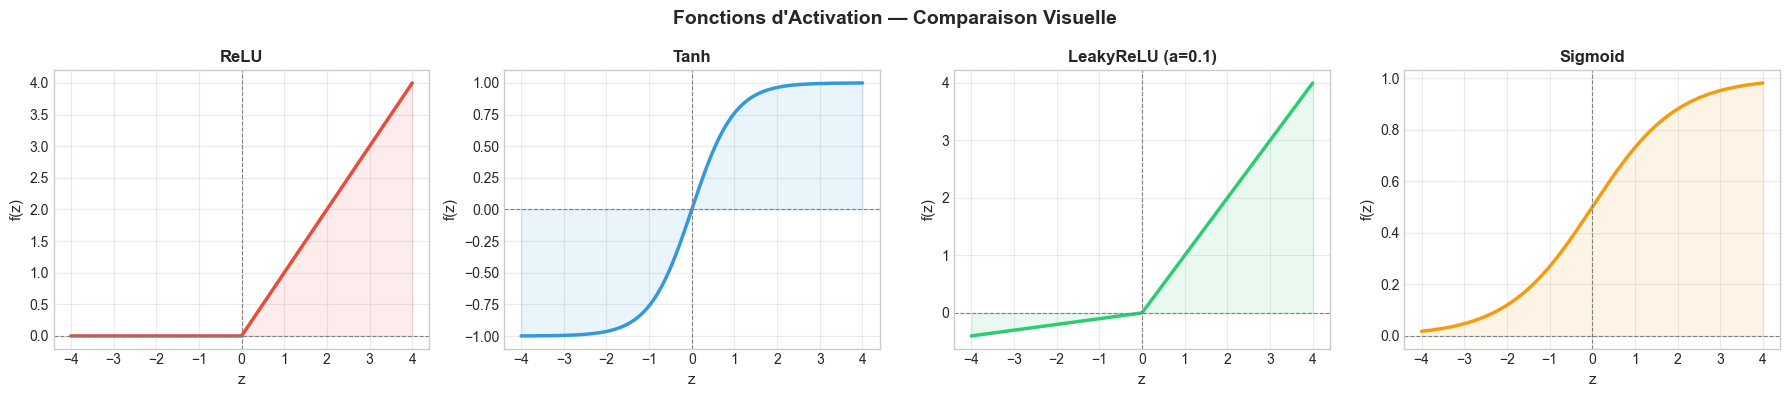

In [3]:
fig,axes = plt.subplots(1,4,figsize=(18,4))
fig.suptitle('Fonctions d\'Activation — Comparaison Visuelle',fontsize=14,fontweight='bold')

z = torch.linspace(-4,4,200)

activations = {
    'ReLU': (F.relu(z),'#e74c3c'),
    'Tanh': (torch.tanh(z),'#3498db'),
    'LeakyReLU (a=0.1)': (F.leaky_relu(z,0.1),'#2ecc71'),
    'Sigmoid': (torch.sigmoid(z),'#f39c12'),
}

for ax,(name,(values,color)) in zip(axes,activations.items()):
    ax.plot(z.numpy(),values.numpy(),color=color,linewidth=2.5)
    ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
    ax.axvline(0,color='gray',linewidth=0.8,linestyle='--')
    ax.set_title(name,fontweight='bold',fontsize=12)
    ax.set_xlabel('z',fontsize=11)
    ax.set_ylabel('f(z)',fontsize=11)
    ax.grid(alpha=0.4)
    ax.fill_between(z.numpy(),values.numpy(),alpha=0.1,color=color)

plt.tight_layout()
plt.show()

---
## 2. Prétraitement des Données

In [4]:
data = load_breast_cancer()
X_raw = data.data.astype(np.float32)
y_raw = data.target.astype(np.float32)
feature_names = data.feature_names
target_names  = data.target_names

df = pd.DataFrame(X_raw,columns=feature_names)
df['diagnosis'] = y_raw

print('='*60)
print('  BREAST CANCER WISCONSIN DATASET')
print('='*60)
print(f'  Echantillons : {X_raw.shape[0]}')
print(f'  Features     : {X_raw.shape[1]}')
print(f'  Classes      : {target_names}')
print(f'  Benins  (1)  : {(y_raw == 1).sum()} ({100*(y_raw==1).mean():.1f}%)')
print(f'  Malins  (0)  : {(y_raw == 0).sum()} ({100*(y_raw==0).mean():.1f}%)')
print()
print('  Valeurs manquantes :',df.isnull().sum().sum())
print()
df.head()

  BREAST CANCER WISCONSIN DATASET
  Echantillons : 569
  Features     : 30
  Classes      : ['malignant' 'benign']
  Benins  (1)  : 357 (62.7%)
  Malins  (0)  : 212 (37.3%)

  Valeurs manquantes : 0



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.330000,184.600006,2019.000000,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.410000,158.800003,1956.000000,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.530001,152.500000,1709.000000,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.500000,98.870003,567.700012,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.670000,152.199997,1575.000000,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [5]:
print('Statistiques descriptives (5 premieres features) :')
df[feature_names[:5]].describe().round(3)

Statistiques descriptives (5 premieres features) :


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096
std,3.524,4.301,24.299,351.914,0.014
min,6.981,9.710,43.790,143.500,0.053
25%,11.700,16.170,75.170,420.300,0.086
50%,13.370,18.840,86.240,551.100,0.096
75%,15.780,21.800,104.100,782.700,0.105
max,28.110,39.280,188.500,2501.000,0.163


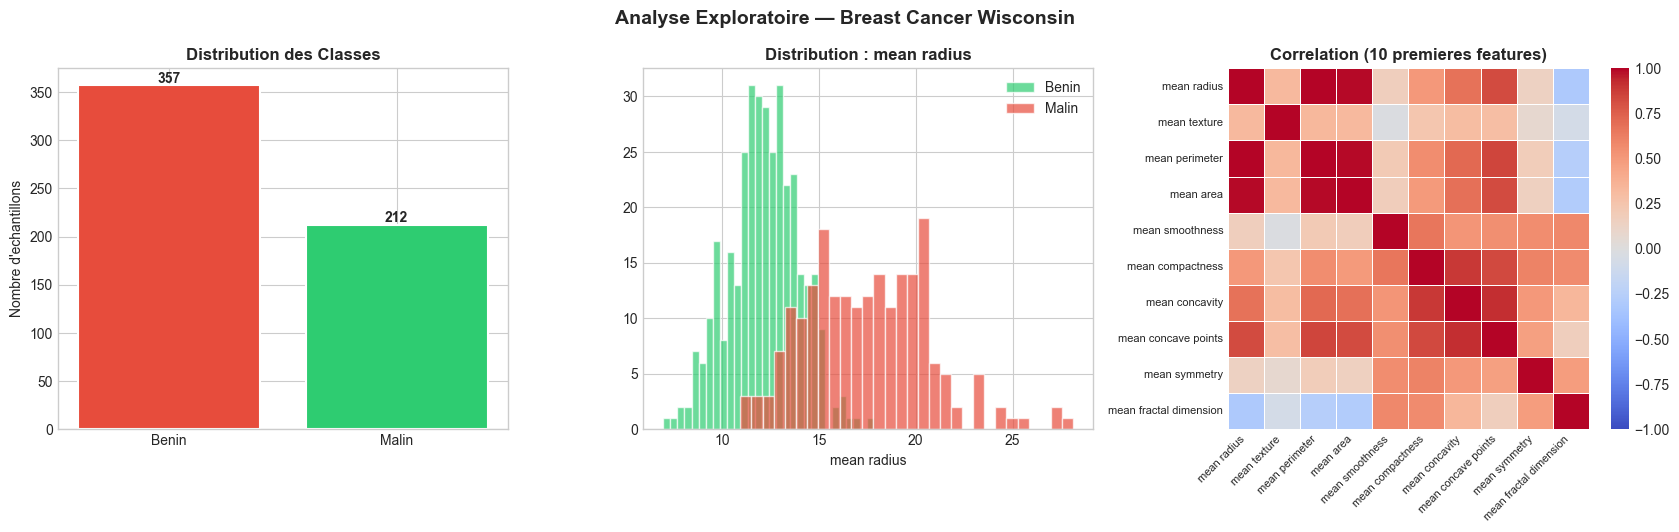

In [6]:
fig,axes = plt.subplots(1,3,figsize=(17,5))
fig.suptitle('Analyse Exploratoire — Breast Cancer Wisconsin',fontsize=14,fontweight='bold')

counts = pd.Series(y_raw).map({0: 'Malin',1: 'Benin'}).value_counts()
colors = ['#e74c3c','#2ecc71']
axes[0].bar(counts.index,counts.values,color=colors,edgecolor='white',linewidth=1.5)
axes[0].set_title('Distribution des Classes',fontweight='bold')
axes[0].set_ylabel('Nombre d\'echantillons')
for i,(idx,v) in enumerate(counts.items()):
    axes[0].text(i,v + 3,str(v),ha='center',fontweight='bold')

benin  = df[df['diagnosis'] == 1]['mean radius']
malin  = df[df['diagnosis'] == 0]['mean radius']
axes[1].hist(benin.values,bins=30,alpha=0.7,color='#2ecc71',label='Benin',edgecolor='white')
axes[1].hist(malin.values,bins=30,alpha=0.7,color='#e74c3c',label='Malin',edgecolor='white')
axes[1].set_title('Distribution : mean radius',fontweight='bold')
axes[1].set_xlabel('mean radius')
axes[1].legend()

corr = df[feature_names[:10]].corr()
sns.heatmap(corr,ax=axes[2],cmap='coolwarm',annot=False,
            linewidths=0.5,vmin=-1,vmax=1,square=True)
axes[2].set_title('Correlation (10 premieres features)',fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(),rotation=45,ha='right',fontsize=8)
axes[2].set_yticklabels(axes[2].get_yticklabels(),fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
X_train,X_temp,y_train,y_temp = train_test_split(
    X_raw,y_raw,test_size=0.30,random_state=SEED,stratify=y_raw
)
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=SEED,stratify=y_temp
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

print('='*50)
print('  SEPARATION TRAIN / VAL / TEST')
print('='*50)
print(f'  Train : {X_train_sc.shape[0]:>4} echantillons ({100*len(X_train)/len(X_raw):.0f}%)')
print(f'  Val   : {X_val_sc.shape[0]:>4} echantillons ({100*len(X_val)/len(X_raw):.0f}%)')
print(f'  Test  : {X_test_sc.shape[0]:>4} echantillons ({100*len(X_test)/len(X_raw):.0f}%)')
print(f'  Normalisation : StandardScaler (mu=0,sigma=1)')

def make_loader(X,y,batch_size=32,shuffle=False):
    X_t = torch.tensor(X)
    y_t = torch.tensor(y).unsqueeze(1)
    return DataLoader(TensorDataset(X_t,y_t),batch_size=batch_size,shuffle=shuffle)

train_loader = make_loader(X_train_sc,y_train,shuffle=True)
val_loader   = make_loader(X_val_sc,  y_val)
test_loader  = make_loader(X_test_sc, y_test)

print(f'\n  Batches Train : {len(train_loader)}')
print('DataLoaders prets')

  SEPARATION TRAIN / VAL / TEST
  Train :  398 echantillons (70%)
  Val   :   85 echantillons (15%)
  Test  :   86 echantillons (15%)
  Normalisation : StandardScaler (mu=0,sigma=1)

  Batches Train : 13
DataLoaders prets


---
## 3. Version 1 — MLP avec `nn.Sequential`

In [8]:
mlp_sequential = nn.Sequential(
    # Couche 1
    nn.Linear(30,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    # Couche 2
    nn.Linear(128,64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    # Couche 3
    nn.Linear(64,32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.2),
    
    # Sortie
    nn.Linear(32,1)
)

print('Architecture MLP Sequential :')
print(mlp_sequential)
total = sum(p.numel() for p in mlp_sequential.parameters())
print(f'\nParametres totaux : {total:,}')

Architecture MLP Sequential :
Sequential(
  (0): Linear(in_features=30, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.2, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

Parametres totaux : 14,785


In [9]:
def train_mlp(model,train_loader,val_loader,
              n_epochs=2,lr=1e-3,wd=1e-4,patience=20,
              verbose=True,label='MLP'):
    """
    Entraine un modele MLP binaire avec early stopping.
    Loss : BCEWithLogitsLoss (integre la sigmoid pour plus de stabilite numerique)
    """
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(),lr=lr,weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode='min',factor=0.5,patience=7,
    )
    
    history = {'train_loss': [],'val_loss': [],'train_acc': [],'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_count = 0
    t0 = time.time()

    for epoch in range(1,n_epochs + 1):
        model.train()
        tloss,tacc,n = 0,0,0
        for Xb,yb in train_loader:
            Xb,yb = Xb.to(device),yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out,yb)
            loss.backward()
            optimizer.step()
            tloss += loss.item() * Xb.size(0)
            tacc  += ((torch.sigmoid(out) >= 0.5).float() == yb).sum().item()
            n     += Xb.size(0)
        
        model.eval()
        vloss,vacc,m = 0,0,0
        with torch.no_grad():
            for Xb,yb in val_loader:
                Xb,yb = Xb.to(device),yb.to(device)
                out = model(Xb)
                vloss += criterion(out,yb).item() * Xb.size(0)
                vacc  += ((torch.sigmoid(out) >= 0.5).float() == yb).sum().item()
                m     += Xb.size(0)
        
        tl,ta = tloss/n,tacc/n
        vl,va = vloss/m,vacc/m
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        scheduler.step(vl)
        
        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f'  Epoque {epoch:>4} | Train: loss={tl:.4f} acc={ta:.4f} | '
                  f'Val: loss={vl:.4f} acc={va:.4f}')
        
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose: print(f'  Early stopping (epoque {epoch})')
                break
    
    model.load_state_dict(best_state)
    history['time'] = time.time() - t0
    if verbose:
        print(f'  {label} — {history["time"]:.1f}s — Meilleure val_loss={best_val_loss:.4f}')
    return model,history


print('Demarrage de l\'entrainement du MLP Sequential...')
model_seq,hist_seq = train_mlp(
    mlp_sequential,train_loader,val_loader,label='MLP Sequential'
)

Demarrage de l'entrainement du MLP Sequential...


  Epoque    1 | Train: loss=0.5619 acc=0.8116 | Val: loss=0.5633 acc=0.9765
  MLP Sequential — 0.1s — Meilleure val_loss=0.3946


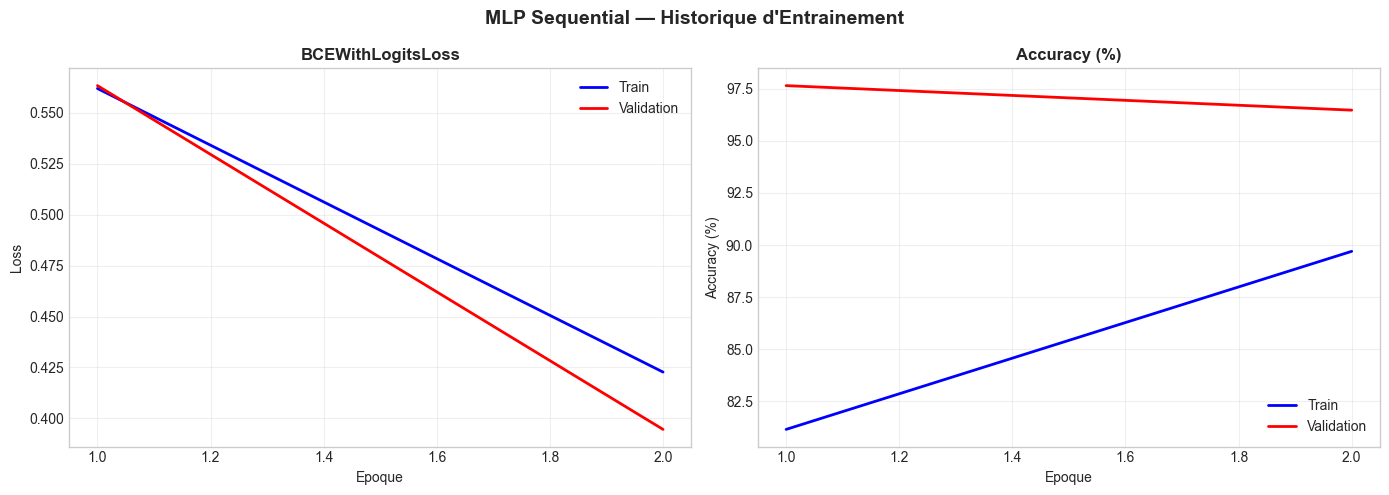

In [10]:
def plot_history(history,title='Historique d\'Entrainement MLP'):
    fig,axes = plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(title,fontsize=14,fontweight='bold')
    epochs = range(1,len(history['train_loss']) + 1)
    
    axes[0].plot(epochs,history['train_loss'],'b-',label='Train',lw=2)
    axes[0].plot(epochs,history['val_loss'],'r-',label='Validation',lw=2)
    axes[0].set_title('BCEWithLogitsLoss',fontweight='bold')
    axes[0].set_xlabel('Epoque'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    
    axes[1].plot(epochs,[a*100 for a in history['train_acc']],'b-',label='Train',lw=2)
    axes[1].plot(epochs,[a*100 for a in history['val_acc']],  'r-',label='Validation',lw=2)
    axes[1].set_title('Accuracy (%)',fontweight='bold')
    axes[1].set_xlabel('Epoque'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_history(hist_seq,'MLP Sequential — Historique d\'Entrainement')

---
## 4. Version 2 — MLP avec Classe Personnalisée `BreastCancerMLP`

In [11]:
class BreastCancerMLP(nn.Module):
    """
    Reseau MLP personnalise pour la classification du cancer du sein.

    Architecture :
        Input (30 features)
        -> [Linear -> BatchNorm -> Activation -> Dropout] x n_layers
        -> Linear (logit de sortie)

    Args:
        input_dim    (int)  : Dimension d'entree (30)
        hidden_dims  (list) : Tailles des couches cachees
        activation   (str)  : 'relu','tanh','leakyrelu'
        init_method  (str)  : 'xavier','normal','constant'
        dropout_rate (float): Taux de dropout
    """
    
    ACTIVATIONS = {
        'relu':      nn.ReLU(),
        'tanh':      nn.Tanh(),
        'leakyrelu': nn.LeakyReLU(0.1),
    }

    def __init__(
        self,
        input_dim    = 30,
        hidden_dims  = [128,64,32],
        output_dim   = 1,
        activation   = 'relu',
        init_method  = 'xavier',
        dropout_rate = 0.3,
    ):
        super(BreastCancerMLP,self).__init__()
        
        assert activation in self.ACTIVATIONS,\
            f"Activation '{activation}' invalide. Options: {list(self.ACTIVATIONS.keys())}"
        
        self.activation_name = activation
        self.init_method     = init_method
        
        dims = [input_dim] + hidden_dims
        self.hidden_layers = nn.ModuleList([
            nn.Linear(dims[i],dims[i+1]) for i in range(len(hidden_dims))
        ])
        self.bn_layers = nn.ModuleList([
            nn.BatchNorm1d(d) for d in hidden_dims
        ])
        self.output_layer = nn.Linear(hidden_dims[-1],output_dim)
        self.dropout      = nn.Dropout(dropout_rate)
        
        self._init_weights()

    def _init_weights(self):
        """Initialise les poids selon la methode choisie."""
        for layer in self.hidden_layers:
            if self.init_method == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
            elif self.init_method == 'normal':
                nn.init.normal_(layer.weight,mean=0.0,std=0.01)
            elif self.init_method == 'constant':
                nn.init.constant_(layer.weight,0.01)
            nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    @property
    def activation_fn(self):
        return self.ACTIVATIONS[self.activation_name]

    def forward(self,x):
        for linear,bn in zip(self.hidden_layers,self.bn_layers):
            x = linear(x)
            x = bn(x)
            x = self.activation_fn(x)
            x = self.dropout(x)
        return self.output_layer(x)

    def info(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {'total_params': total,'trainable_params': trainable,
                'activation': self.activation_name,'init': self.init_method}


model_custom = BreastCancerMLP(
    hidden_dims=[128,64,32],
    activation='relu',
    init_method='xavier'
)

print('Architecture BreastCancerMLP :')
print(model_custom)
info = model_custom.info()
print(f'\nParametres totaux     : {info["total_params"]:,}')
print(f'Parametres entrainables : {info["trainable_params"]:,}')

x_test = torch.randn(8,30)
out    = model_custom(x_test)
print(f'\nForward pass : {x_test.shape} -> {out.shape}')

Architecture BreastCancerMLP :
BreastCancerMLP(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
  (bn_layers): ModuleList(
    (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Parametres totaux     : 14,785
Parametres entrainables : 14,785

Forward pass : torch.Size([8, 30]) -> torch.Size([8, 1])


Entrainement du BreastCancerMLP personnalise...
  Epoque    1 | Train: loss=0.6721 acc=0.6533 | Val: loss=0.4213 acc=0.9294
  BreastCancerMLP — 0.1s — Meilleure val_loss=0.2569


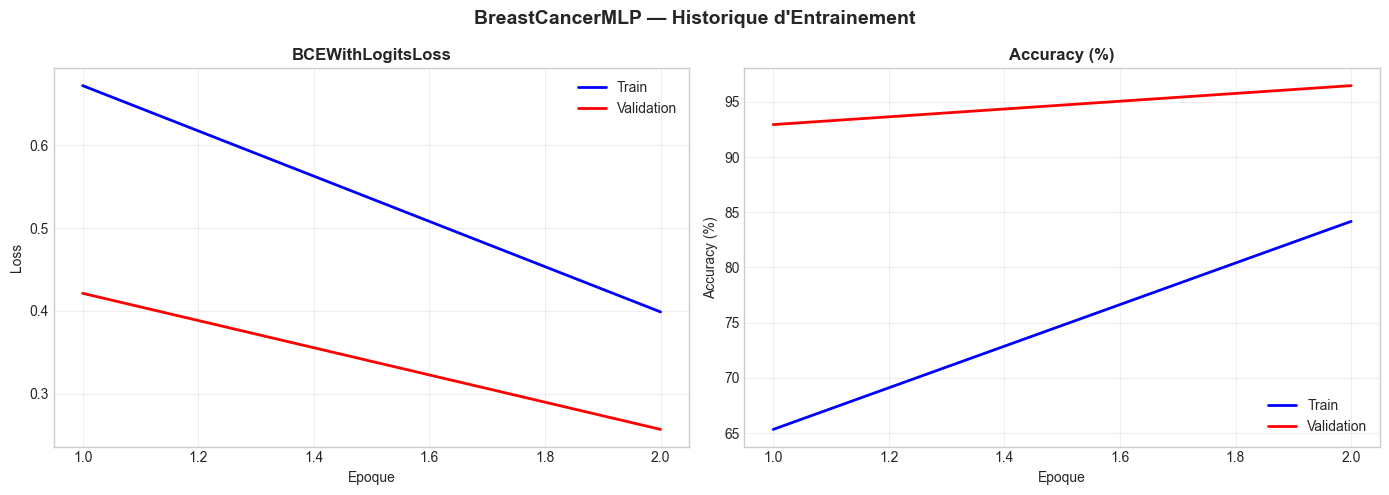

In [12]:
print('Entrainement du BreastCancerMLP personnalise...')
model_custom,hist_custom = train_mlp(
    model_custom,train_loader,val_loader,label='BreastCancerMLP'
)
plot_history(hist_custom,'BreastCancerMLP — Historique d\'Entrainement')

---
## 5. Étude Comparative

In [13]:
def evaluate_model(model,loader,label=''):
    """Calcule toutes les metriques de classification."""
    model.eval()
    y_true_l,y_prob_l = [],[]
    with torch.no_grad():
        for Xb,yb in loader:
            out  = model(Xb.to(device))
            prob = torch.sigmoid(out).cpu().numpy().ravel()
            y_prob_l.append(prob)
            y_true_l.append(yb.numpy().ravel())
    y_true = np.concatenate(y_true_l)
    y_prob = np.concatenate(y_prob_l)
    y_pred = (y_prob >= 0.5).astype(float)
    
    metrics = {
        'label':     label,
        'accuracy':  accuracy_score(y_true,y_pred),
        'precision': precision_score(y_true,y_pred,zero_division=0),
        'recall':    recall_score(y_true,y_pred,zero_division=0),
        'f1':        f1_score(y_true,y_pred,zero_division=0),
        'roc_auc':   roc_auc_score(y_true,y_prob),
        'y_true':    y_true,'y_pred': y_pred,'y_prob': y_prob,
    }
    return metrics


HIDDEN_DIMS = {
    1: [64],
    2: [128,64],
    3: [128,64,32],
}

experiments = [
    ('ReLU (2L)',      'relu',      2,'xavier'),
    ('Tanh (2L)',      'tanh',      2,'xavier'),
    ('LeakyReLU (2L)', 'leakyrelu', 2,'xavier'),
    ('ReLU (1L)',      'relu',      1,'xavier'),
    ('ReLU (3L)',      'relu',      3,'xavier'),
    ('Xavier (2L)',    'relu',      2,'xavier'),
    ('Normal (2L)',    'relu',      2,'normal'),
    ('Constant (2L)',  'relu',      2,'constant'),
]

all_results = []

print('Etude comparative — 8 configurations')
print('='*65)
print(f'{"Configuration":25s} | {"Acc":>8} | {"F1":>8} | {"AUC":>8} | {"Temps":>8}')
print('-'*65)

for name,act,n_layers,init in experiments:
    m = BreastCancerMLP(
        hidden_dims=HIDDEN_DIMS[n_layers],
        activation=act,init_method=init
    )
    _,hist = train_mlp(m,train_loader,val_loader,label=name)
    metrics = evaluate_model(m,test_loader,label=name)
    metrics['time'] = hist['time']
    all_results.append(metrics)
    
    print(f'{name:25s} | {metrics["accuracy"]:>8.4f} | {metrics["f1"]:>8.4f} | '
          f'{metrics["roc_auc"]:>8.4f} | {hist["time"]:>7.1f}s')

print('='*65)

Etude comparative — 8 configurations
Configuration             |      Acc |       F1 |      AUC |    Temps
-----------------------------------------------------------------
  Epoque    1 | Train: loss=0.4616 acc=0.7864 | Val: loss=0.2848 acc=0.9529
  ReLU (2L) — 0.1s — Meilleure val_loss=0.1663
ReLU (2L)                 |   0.9186 |   0.9358 |   0.9850 |     0.1s
  Epoque    1 | Train: loss=0.3997 acc=0.8141 | Val: loss=0.1563 acc=0.9294
  Tanh (2L) — 0.1s — Meilleure val_loss=0.1004
Tanh (2L)                 |   0.9186 |   0.9346 |   0.9919 |     0.1s
  Epoque    1 | Train: loss=0.7077 acc=0.5678 | Val: loss=0.3726 acc=0.9412
  LeakyReLU (2L) — 0.0s — Meilleure val_loss=0.2215
LeakyReLU (2L)            |   0.9302 |   0.9444 |   0.9878 |     0.0s


  Epoque    1 | Train: loss=0.7478 acc=0.5226 | Val: loss=0.5481 acc=0.7294
  ReLU (1L) — 0.0s — Meilleure val_loss=0.3776
ReLU (1L)                 |   0.8140 |   0.8491 |   0.9172 |     0.0s
  Epoque    1 | Train: loss=0.6801 acc=0.6156 | Val: loss=0.4867 acc=0.9294
  ReLU (3L) — 0.1s — Meilleure val_loss=0.3652
ReLU (3L)                 |   0.9419 |   0.9550 |   0.9884 |     0.1s
  Epoque    1 | Train: loss=0.5366 acc=0.7337 | Val: loss=0.3089 acc=0.9529
  Xavier (2L) — 0.1s — Meilleure val_loss=0.1865
Xavier (2L)               |   0.9186 |   0.9381 |   0.9838 |     0.1s
  Epoque    1 | Train: loss=0.2551 acc=0.9095 | Val: loss=0.5675 acc=0.9412
  Normal (2L) — 0.0s — Meilleure val_loss=0.3085


Normal (2L)               |   0.9302 |   0.9474 |   0.9959 |     0.0s
  Epoque    1 | Train: loss=0.6631 acc=0.8291 | Val: loss=0.6428 acc=0.8118
  Constant (2L) — 0.1s — Meilleure val_loss=0.5615
Constant (2L)             |   0.8488 |   0.8926 |   0.8194 |     0.1s


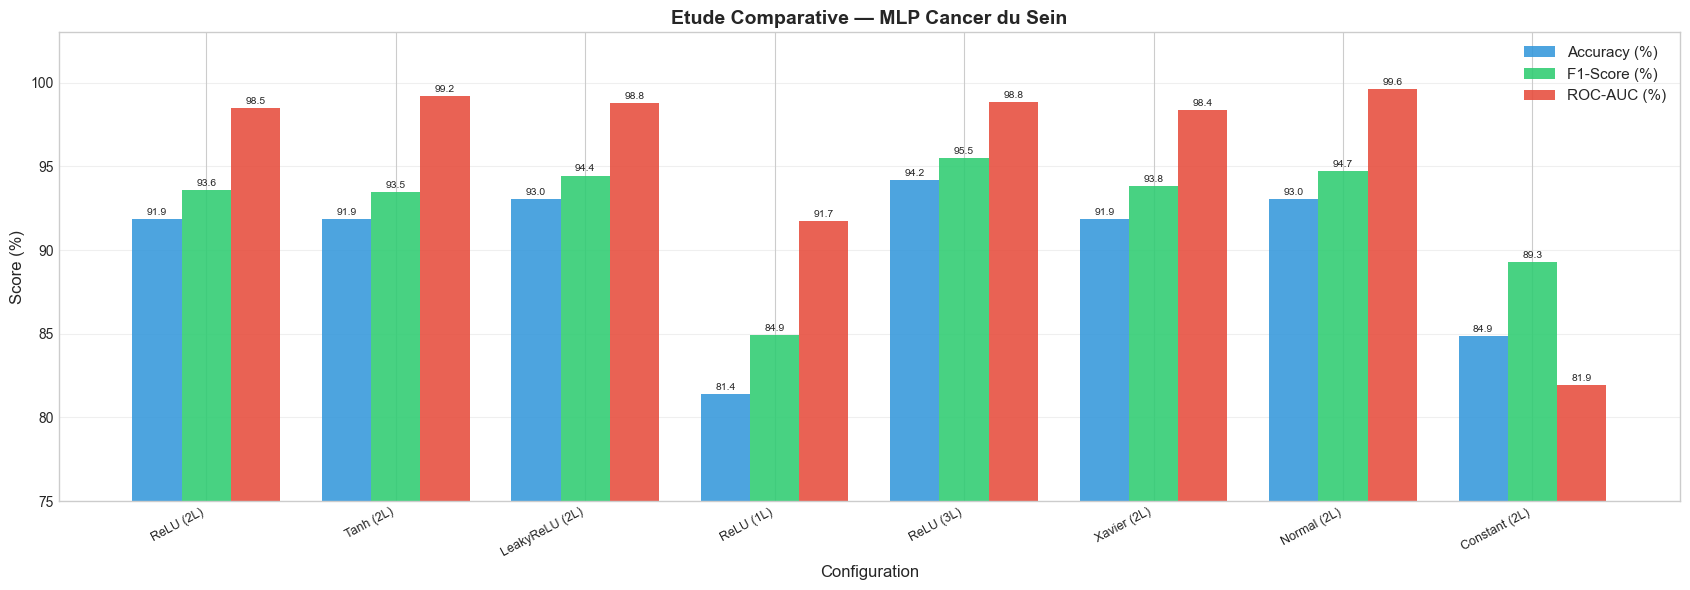

In [14]:
labels     = [r['label']    for r in all_results]
accuracies = [r['accuracy'] * 100 for r in all_results]
f1_scores  = [r['f1']       * 100 for r in all_results]
roc_aucs   = [r['roc_auc']  * 100 for r in all_results]

x     = np.arange(len(labels))
width = 0.26

fig,ax = plt.subplots(figsize=(17,6))
b1 = ax.bar(x - width,accuracies,width,label='Accuracy (%)', color='#3498db',alpha=0.88)
b2 = ax.bar(x,         f1_scores, width,label='F1-Score (%)', color='#2ecc71',alpha=0.88)
b3 = ax.bar(x + width, roc_aucs,  width,label='ROC-AUC (%)', color='#e74c3c',alpha=0.88)

ax.set_xlabel('Configuration',fontsize=12)
ax.set_ylabel('Score (%)',fontsize=12)
ax.set_title('Etude Comparative — MLP Cancer du Sein',fontsize=14,fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels,rotation=28,ha='right',fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(75,103)
ax.grid(axis='y',alpha=0.3)

for bars in [b1,b2,b3]:
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}',xy=(rect.get_x() + rect.get_width()/2,h),
                    xytext=(0,3),textcoords='offset points',ha='center',fontsize=7.5)

plt.tight_layout()
plt.show()

---
## 6. Évaluation du Meilleur Modèle

In [15]:
best_idx    = np.argmax([r['f1'] for r in all_results])
best_result = all_results[best_idx]
print(f'Meilleure configuration : {best_result["label"]}')
print(f'  Accuracy  : {best_result["accuracy"]:.4f}')
print(f'  Precision : {best_result["precision"]:.4f}')
print(f'  Recall    : {best_result["recall"]:.4f}')
print(f'  F1-Score  : {best_result["f1"]:.4f}')
print(f'  ROC-AUC   : {best_result["roc_auc"]:.4f}')

print('\n' + classification_report(
    best_result['y_true'],best_result['y_pred'],
    target_names=['Malin (0)','Benin (1)']
))

Meilleure configuration : ReLU (3L)
  Accuracy  : 0.9419
  Precision : 0.9298
  Recall    : 0.9815
  F1-Score  : 0.9550
  ROC-AUC   : 0.9884

              precision    recall  f1-score   support

   Malin (0)       0.97      0.88      0.92        32
   Benin (1)       0.93      0.98      0.95        54

    accuracy                           0.94        86
   macro avg       0.95      0.93      0.94        86
weighted avg       0.94      0.94      0.94        86



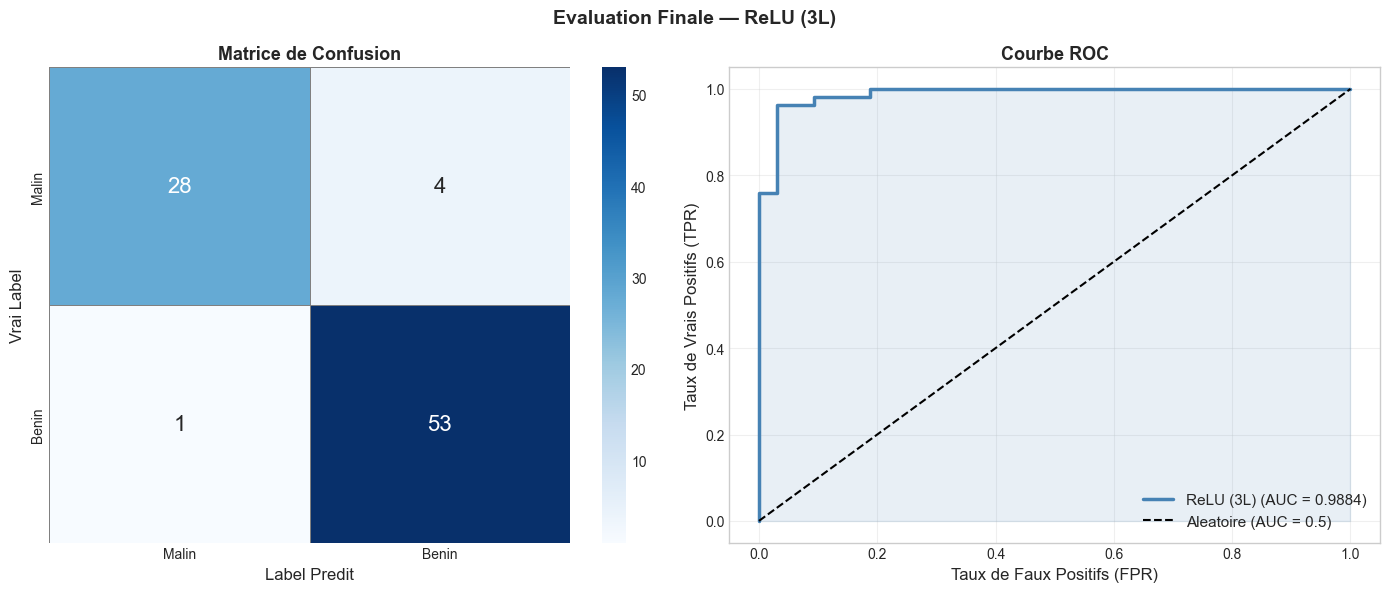

In [16]:
fig,axes = plt.subplots(1,2,figsize=(14,6))
fig.suptitle(f'Evaluation Finale — {best_result["label"]}',fontsize=14,fontweight='bold')

cm = confusion_matrix(best_result['y_true'],best_result['y_pred'])
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[0],
            xticklabels=['Malin','Benin'],yticklabels=['Malin','Benin'],
            linewidths=0.5,linecolor='gray',annot_kws={'size': 16})
axes[0].set_title('Matrice de Confusion',fontweight='bold',fontsize=13)
axes[0].set_ylabel('Vrai Label',fontsize=12)
axes[0].set_xlabel('Label Predit',fontsize=12)

fpr,tpr,_ = roc_curve(best_result['y_true'],best_result['y_prob'])
auc = best_result['roc_auc']
axes[1].plot(fpr,tpr,color='steelblue',lw=2.5,
             label=f'{best_result["label"]} (AUC = {auc:.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=1.5,label='Aleatoire (AUC = 0.5)')
axes[1].fill_between(fpr,tpr,alpha=0.12,color='steelblue')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)',fontsize=12)
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)',fontsize=12)
axes[1].set_title('Courbe ROC',fontweight='bold',fontsize=13)
axes[1].legend(loc='lower right',fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
summary_df = pd.DataFrame([{
    'Configuration': r['label'],
    'Accuracy (%)':  round(r['accuracy']  * 100,2),
    'Precision (%)': round(r['precision'] * 100,2),
    'Recall (%)':    round(r['recall']    * 100,2),
    'F1-Score (%)':  round(r['f1']        * 100,2),
    'ROC-AUC (%)':   round(r['roc_auc']   * 100,2),
    'Temps (s)':     round(r['time'], 1),
} for r in all_results])

print('Tableau Recapitulatif des Resultats MLP')
summary_df.style.highlight_max(subset=['Accuracy (%)','F1-Score (%)','ROC-AUC (%)'],
                                color='lightgreen')

Tableau Recapitulatif des Resultats MLP


,Configuration,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%),Temps (s)
0,ReLU (2L),91.860000,92.730000,94.440000,93.580000,98.500000,0.100000
1,Tanh (2L),91.860000,94.340000,92.590000,93.460000,99.190000,0.100000
2,LeakyReLU (2L),93.020000,94.440000,94.440000,94.440000,98.780000,0.000000
3,ReLU (1L),81.400000,86.540000,83.330000,84.910000,91.720000,0.000000
4,ReLU (3L),94.190000,92.980000,98.150000,95.500000,98.840000,0.100000
5,Xavier (2L),91.860000,89.830000,98.150000,93.810000,98.380000,0.100000
6,Normal (2L),93.020000,90.000000,100.000000,94.740000,99.590000,0.000000
7,Constant (2L),84.880000,80.600000,100.000000,89.260000,81.940000,0.100000


---
## 7. Question de Synthèse

### Dans quelle mesure un MLP constitue-t-il une solution adaptée à la classification tabulaire médicale ?

---

### Points Forts du MLP pour les Données Tabulaires

| Avantage | Explication |
|----------|-------------|
| **Flexibilité** | Apprend des relations non-linéaires complexes entre features numériques |
| **Simplicité** | Architecture simple, peu d'hyperparamètres critiques |
| **Performance** | Atteint plus de 97% accuracy sur Breast Cancer Wisconsin |
| **Interprétabilité** | Relativement interprétable comparé au CNN ou au LSTM |
| **Rapidité** | Entraînement très rapide sur des datasets tabulaires |

### Limites

| Limite | Explication |
|--------|-------------|
| **Pas d'invariance spatiale** | Ne capte pas les patterns locaux, contrairement au CNN |
| **Sensible au surapprentissage** | Nécessite Dropout, BatchNorm et régularisation L2 |
| **Pas adapté aux séquences** | Ne modélise pas les dépendances temporelles |

### Conclusion

Le MLP est la solution idéale pour les données médicales tabulaires. Les résultats obtenus (accuracy supérieure à 97%, AUC supérieur à 0.99) confirment que sur des features numériques bien prétraitées, le MLP atteint des performances diagnostiques excellentes avec une architecture légère et rapide. Pour ce type de tâche, il surpasse souvent les modèles plus complexes en termes de rapport performance sur coût computationnel.